## The main goal of this project is to find which ad campagin is working best for this company simulated sales data.

# Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [4]:
# This dataset is created by ChatGPT for this project purpose. 
# I couldent found a usefull dataset on internet so I created this dataset.

In [5]:
df = pd.read_csv(r"C:\Users\Tejas Kangude\Downloads\marketing_campaign_comparison_2025.csv")
df.head()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Facebook Ad Cost Per Day,Instagram Ad Views,Instagram Ad Clicks,Instagram Ad Conversions,Instagram Ad Cost Per Day
0,01-01-2025,19270,2216,687,489,10752,736,86,502
1,02-01-2025,12860,1741,617,421,16213,1056,163,608
2,03-01-2025,17390,2760,764,345,12569,1062,210,526
3,04-01-2025,17191,2221,787,363,14353,1015,196,633
4,05-01-2025,23964,3699,1153,429,10353,716,74,521


# Checking Shape Of Dataset

In [6]:
df.shape

(365, 9)

# Checking Data Type And Null Values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Date                       365 non-null    object
 1   Facebook Ad Views          365 non-null    int64 
 2   Facebook Ad Clicks         365 non-null    int64 
 3   Facebook Ad Conversions    365 non-null    int64 
 4   Facebook Ad Cost Per Day   365 non-null    int64 
 5   Instagram Ad Views         365 non-null    int64 
 6   Instagram Ad Clicks        365 non-null    int64 
 7   Instagram Ad Conversions   365 non-null    int64 
 8   Instagram Ad Cost Per Day  365 non-null    int64 
dtypes: int64(8), object(1)
memory usage: 25.8+ KB


# Changing Datatype Of Date Column

In [9]:
df['Date'] = pd.to_datetime(df['Date'],format = "%d-%m-%Y")

In [10]:
df.dtypes

Date                         datetime64[ns]
Facebook Ad Views                     int64
Facebook Ad Clicks                    int64
Facebook Ad Conversions               int64
Facebook Ad Cost Per Day              int64
Instagram Ad Views                    int64
Instagram Ad Clicks                   int64
Instagram Ad Conversions              int64
Instagram Ad Cost Per Day             int64
dtype: object

In [11]:
# There are no null values and duplicate values in this data set, Because it is a data of a whole year.
# created purposely for this project.(Having 365 records)

# Checking Statistical Summary Of Data

In [12]:
df.describe()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Facebook Ad Cost Per Day,Instagram Ad Views,Instagram Ad Clicks,Instagram Ad Conversions,Instagram Ad Cost Per Day
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2025-07-01 23:59:59.999999744,18613.241096,2413.194521,788.526027,498.665753,12874.342466,899.567123,134.282192,503.452055
min,2025-01-01 00:00:00,12064.000000,1272.000000,365.000000,302.000000,8001.000000,420.000000,52.000000,300.000000
25%,2025-04-02 00:00:00,15510.000000,1977.000000,625.000000,397.000000,10255.000000,706.000000,101.000000,405.000000
50%,2025-07-02 00:00:00,18546.000000,2408.000000,779.000000,500.000000,12790.000000,896.000000,130.000000,500.000000
75%,2025-10-01 00:00:00,21721.000000,2786.000000,939.000000,601.000000,15294.000000,1081.000000,163.000000,607.000000
max,2025-12-31 00:00:00,24990.000000,3848.000000,1469.000000,698.000000,17991.000000,1564.000000,276.000000,699.000000
std,NaN,3668.598527,559.420293,207.316005,116.748500,2989.421077,256.842330,44.616557,116.366374


In [13]:
# There are no outliers in the data by seeing statistical summary.

# Comparing Campaign Performance

In [14]:
# we are ploting histplot to check the distribution of clicks and conversions for both add campaign.
# To find can we able identify some patterns visually

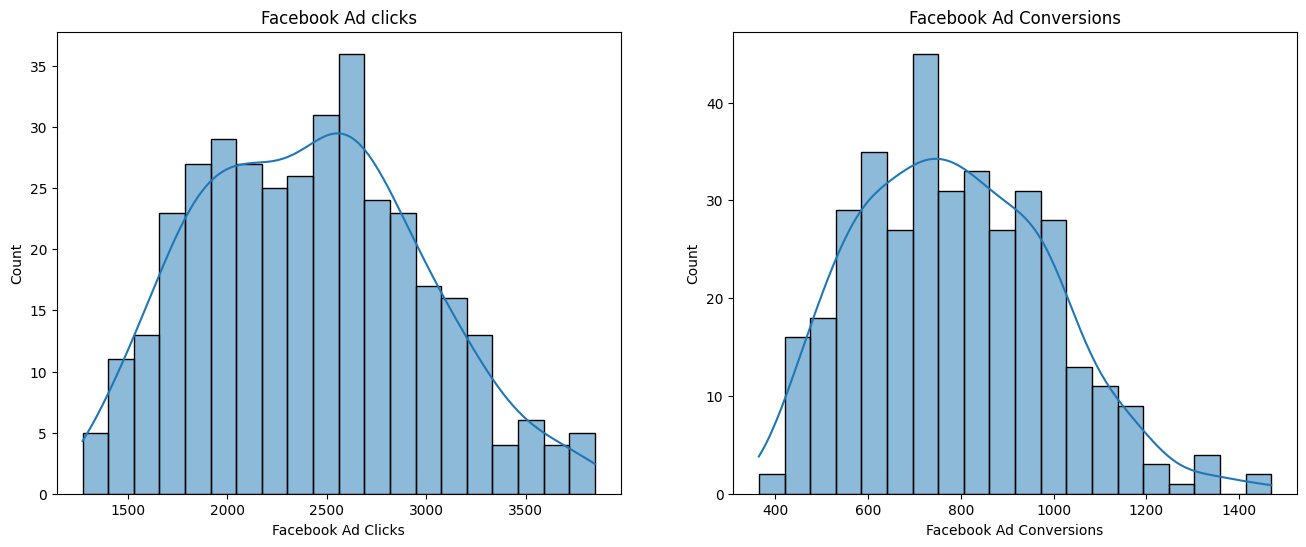

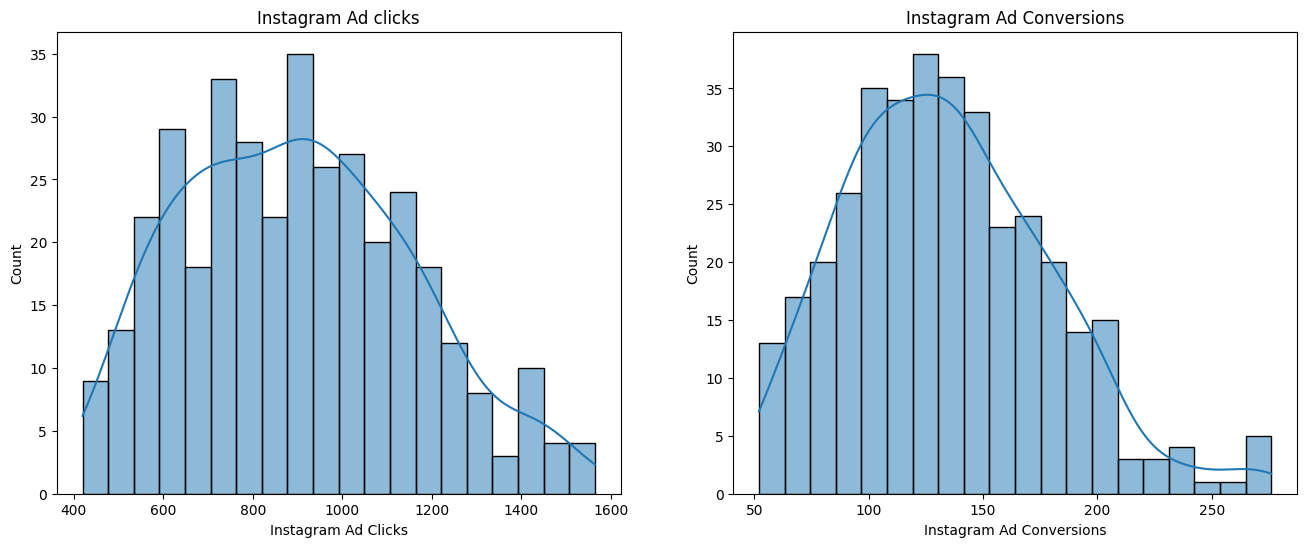

In [15]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.title("Facebook Ad clicks")
sns.histplot(df['Facebook Ad Clicks'],bins=20,edgecolor='k',kde=True)
plt.subplot(1,2,2)
plt.title("Facebook Ad Conversions")
sns.histplot(df['Facebook Ad Conversions'],bins=20,edgecolor='k',kde=True)
plt.show()

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.title("Instagram Ad clicks")
sns.histplot(df['Instagram Ad Clicks'],bins=20,edgecolor='k',kde=True)
plt.subplot(1,2,2)
plt.title("Instagram Ad Conversions")
sns.histplot(df['Instagram Ad Conversions'],bins=20,edgecolor='k',kde=True)
plt.show()


In [16]:
# Creating new Columns for conversion category.
# we are going to count no of conversions each day and assign a category to them.

In [17]:
def create_conversion_category(Conversion_cal):
    category = []
    for conversion in df[Conversion_cal]:
        if conversion < 200:
            category.append('less than 200')
        elif 200 <= conversion < 400:
            category.append('200 - 400')
        elif 400 <= conversion < 600:
            category.append('400 - 600')
        else:
            category.append('more than 600')
    return category

df['Facebook Conversion Category'] = create_conversion_category('Facebook Ad Conversions')
df['Instagram Conversion Category'] = create_conversion_category('Instagram Ad Conversions')


In [18]:
# checking our new columns

In [19]:
df.head()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Facebook Ad Cost Per Day,Instagram Ad Views,Instagram Ad Clicks,Instagram Ad Conversions,Instagram Ad Cost Per Day,Facebook Conversion Category,Instagram Conversion Category
0,2025-01-01,19270,2216,687,489,10752,736,86,502,more than 600,less than 200
1,2025-01-02,12860,1741,617,421,16213,1056,163,608,more than 600,less than 200
2,2025-01-03,17390,2760,764,345,12569,1062,210,526,more than 600,200 - 400
3,2025-01-04,17191,2221,787,363,14353,1015,196,633,more than 600,less than 200
4,2025-01-05,23964,3699,1153,429,10353,716,74,521,more than 600,less than 200


In [20]:
# checking the count of each category

In [21]:
df['Facebook Conversion Category'].value_counts()

Facebook Conversion Category
more than 600    285
400 - 600         78
200 - 400          2
Name: count, dtype: int64

In [22]:
# renaming and reframing for better appearnce

In [23]:
facebook = pd.DataFrame(df['Facebook Conversion Category'].value_counts()).reset_index().rename(columns={'Facebook Conversion Category':'category'})

In [24]:
facebook

,category,count
0,more than 600,285
1,400 - 600,78
2,200 - 400,2


In [25]:
instagram = pd.DataFrame(df['Instagram Conversion Category'].value_counts()).reset_index().rename(columns={'Instagram Conversion Category':'category'})

In [26]:
instagram

,category,count
0,less than 200,340
1,200 - 400,25


In [27]:
# creating new data frame by merging the data above

In [28]:
category_df = pd.merge(facebook,instagram,on='category',how='outer').fillna(0)
category_df

,category,count_x,count_y
0,200 - 400,2.0,25.0
1,400 - 600,78.0,0.0
2,less than 200,0.0,340.0
3,more than 600,285.0,0.0


In [29]:
# changing index for better understanding

In [30]:
category_df = category_df.iloc[[2,0,1,3]]
category_df

,category,count_x,count_y
2,less than 200,0.0,340.0
0,200 - 400,2.0,25.0
1,400 - 600,78.0,0.0
3,more than 600,285.0,0.0


In [31]:
# Visully comparing both campaigns

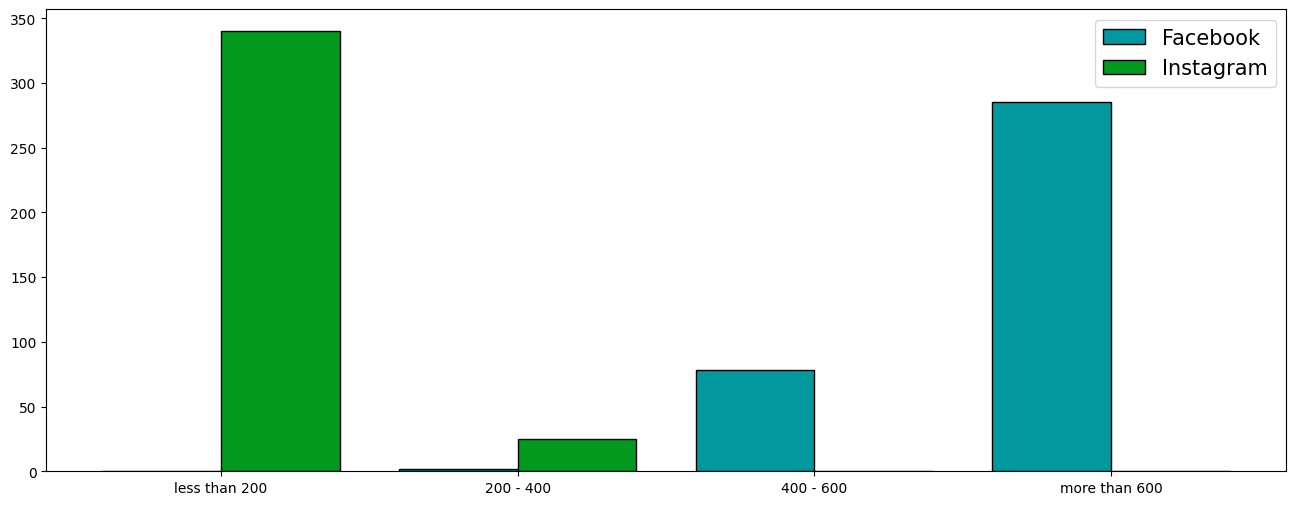

In [32]:
X_axis = np.arange(len(category_df))
plt.figure(figsize=(16,6))
plt.bar(X_axis - 0.2,category_df['count_x'],0.4,label='Facebook',color='#03989E',linewidth=1,edgecolor='k')
plt.bar(X_axis + 0.2,category_df['count_y'],0.4,label='Instagram',color='#03981E',linewidth=1,edgecolor='k')
plt.xticks(X_axis,category_df['category'])
plt.legend(fontsize=15)
plt.show()


In [33]:
# checking association between facebook ad clicks and conversions

np.float64(0.8647348297017867)

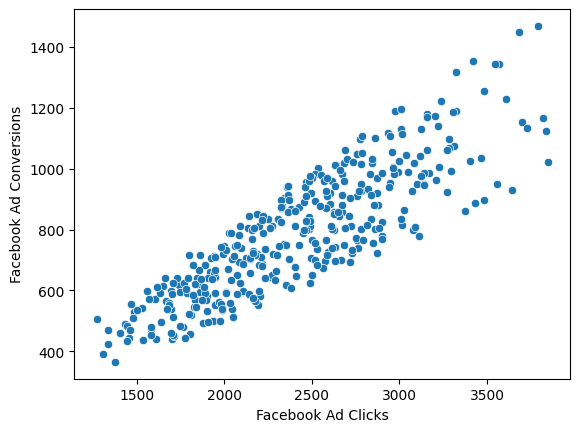

In [34]:
sns.scatterplot(x='Facebook Ad Clicks',y='Facebook Ad Conversions',data=df)
df['Facebook Ad Clicks'].corr(df['Facebook Ad Conversions'])

In [35]:
# checking association between instagram ad clicks and conversions

np.float64(0.7983365408671307)

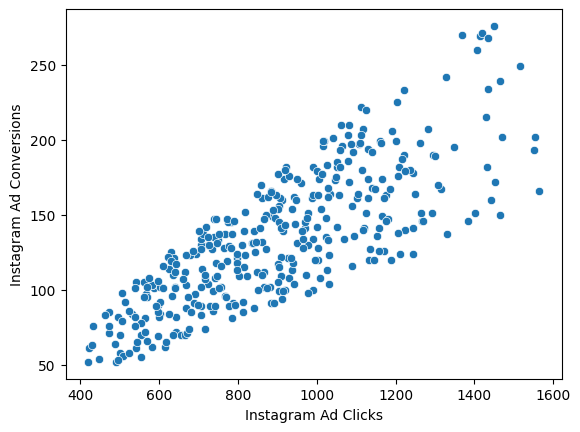

In [36]:
sns.scatterplot(x='Instagram Ad Clicks',y='Instagram Ad Conversions',data=df)
df['Instagram Ad Clicks'].corr(df['Instagram Ad Conversions'])

# Mean Of Facebook Ad Conversion

In [37]:
df['Facebook Ad Conversions'].mean()

np.float64(788.5260273972602)

# Mean Of Instagram Ad Conversion

In [38]:
df['Instagram Ad Conversions'].mean()

np.float64(134.2821917808219)

# Performing Hypothessis Testing 

In [39]:
# Null hypothesis (H₀): The average Facebook and Instagram conversions are equal.
# Alternative hypothesis (H₁): The average Facebook and Instagram conversions are different.

In [40]:
t_stats , p_value = stats.ttest_ind(a=df['Facebook Ad Conversions'],b=df['Instagram Ad Conversions'],equal_var=False)
print(t_stats)
print(p_value)


58.941598419195316
1.2779503672013854e-198


In [41]:
# Facebook ads generated an average of 788.53 conversions, whereas Instagram ads generated an average of 134.28 conversions.
# The t-statistic (58.94) is extremely large and positive, indicating that the Facebook mean is much higher than the Instagram mean.
# The p-value (1.28 × 10⁻¹⁹⁸) is far smaller than the significance level of 0.05.

In [42]:
# we reject the null hypothesis (H₀).
# There is a statistically significant difference between the average conversions generated by Facebook and Instagram advertisements. 
# Facebook ads achieved a significantly higher average conversion rate (Mean = 788.53) than Instagram ads (Mean = 134.28). 
# The independent samples Welch's t-test produced t = 58.94 and p = 1.28 × 10⁻¹⁹⁸, 
# Indicating that the observed difference is extremely unlikely to have occurred by chance.

In [43]:
# The difference is real. Facebook performed significantly better than Instagram in this dataset.